In [1]:
import sys
from pathlib import Path

# make the project root importable when the notebook runs from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import datetime as dt

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import cm

from src.data.data_loader import DataLoader


In [2]:
loader = DataLoader()

# ~10 years of daily SPX history; end=today+1 because yfinance end is exclusive
spx = loader.load_spx(
    start="2016-01-01",
    end=str(dt.date.today() + dt.timedelta(days=1)),
    interval="1d",
)

# yfinance returns MultiIndex columns even for one ticker -> flatten
if isinstance(spx.columns, pd.MultiIndex):
    spx.columns = spx.columns.droplevel(1)

S0 = float(spx["Close"].iloc[-1])   # spot anchor for the snapshot
print(spx.shape, "  S0 =", S0)
spx.tail()

[*********************100%***********************]  1 of 1 completed

(2628, 5)   S0 = 7517.33984375


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-06-10,7266.990234,7396.560059,7265.930176,7350.540039,5247300000
2026-06-11,7394.299805,7412.680176,7257.330078,7287.669922,5658920000
2026-06-12,7431.459961,7456.399902,7363.009766,7410.850098,4950530000
2026-06-15,7554.290039,7577.919922,7516.750000,7516.750000,5674670000
2026-06-16,7517.339844,7564.959961,7511.629883,7548.779785,2198021581


In [3]:
chain = loader.load_option_chain(ticker="^SPX", n_maturities=10)
chain.tail()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,expiry,type,spot,snapshot_time,ttm
4415,SPX270617P10000000,2026-06-01 18:00:10+00:00,10000.0,2036.89,2119.9,2126.8,0.000000,0.000000,1.0,0.0,0.000010,True,REGULAR,USD,2027-06-17,put,7517.08,2026-06-16 19:57:01+00:00,1.000462
4416,SPX270617P10200000,2026-06-16 18:56:26+00:00,10200.0,2298.56,2306.0,2313.0,42.430176,1.880662,3.0,19.0,0.000010,True,REGULAR,USD,2027-06-17,put,7517.08,2026-06-16 19:57:01+00:00,1.000462
4417,SPX270617P10400000,2026-06-01 18:00:10+00:00,10400.0,2407.73,2494.8,2502.3,0.000000,0.000000,1.0,1.0,0.000010,True,REGULAR,USD,2027-06-17,put,7517.08,2026-06-16 19:57:01+00:00,1.000462
4418,SPX270617P10600000,2026-06-01 18:00:10+00:00,10600.0,2596.24,2684.0,2692.0,0.000000,0.000000,1.0,17.0,0.000010,True,REGULAR,USD,2027-06-17,put,7517.08,2026-06-16 19:57:01+00:00,1.000462
4419,SPX270617P10800000,2026-03-06 14:51:34+00:00,10800.0,3638.01,3571.3,3975.1,0.000000,0.000000,17.0,0.0,0.530325,True,REGULAR,USD,2027-06-17,put,7517.08,2026-06-16 19:57:01+00:00,1.000462


In [4]:
chain.to_parquet(ROOT / "data" / "spx_option_chain.parquet")
spx.to_parquet(ROOT / "data" / "spx_price.parquet")

In [9]:
import pyarrow.parquet as pq

chain = (
     pq.read_table(ROOT / "data" / "spx_option_chain.parquet")
       .replace_schema_metadata(None)
       .to_pandas()
 )

# --- prep: keep calls, build a clean mid price and time-to-maturity ---
calls = chain[chain["type"] == "call"].copy()
calls = calls[(calls.ttm > 0) & (calls.bid > 0) & (calls.ask > 0)].dropna(subset=["strike", "bid", "ask", "lastPrice"])

# mid price is more reliable than lastPrice; fall back if bid/ask missing
if {"bid", "ask"}.issubset(calls.columns):
    calls["mid"] = (calls["bid"] + calls["ask"]) / 2
    calls.loc[calls["mid"] <= 0, "mid"] = calls["lastPrice"]
else:
    calls["mid"] = calls["lastPrice"]

# time to maturity in YEARS
calls["ttm"] = (pd.to_datetime(calls["expiry"]) - pd.Timestamp.today()).dt.days / 365

# basic liquidity / sanity filter
calls = calls[(calls["mid"] > 0) & (calls["ttm"] > 0)].dropna(subset=["strike", "mid", "ttm"])
print(calls.shape)
calls.head()

(1899, 20)


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,expiry,type,spot,snapshot_time,ttm,mid
0,SPXW260623C06600000,2026-05-28 16:48:01+00:00,6600.0,981.57,914.2,933.5,0.00000,0.000000,2.0,1.0,0.574620,True,REGULAR,USD,2026-06-23,call,7517.08,2026-06-16 19:57:01+00:00,0.016438,923.85
1,SPXW260623C06675000,2026-06-11 18:32:45+00:00,6675.0,697.19,840.3,857.8,0.00000,0.000000,NaN,1.0,0.529591,True,REGULAR,USD,2026-06-23,call,7517.08,2026-06-16 19:57:01+00:00,0.016438,849.05
2,SPXW260623C06700000,2026-06-11 18:32:45+00:00,6700.0,672.64,814.3,832.7,0.00000,0.000000,NaN,1.0,0.515653,True,REGULAR,USD,2026-06-23,call,7517.08,2026-06-16 19:57:01+00:00,0.016438,823.50
3,SPXW260623C06750000,2026-06-16 19:05:51+00:00,6750.0,781.58,763.7,783.9,-29.95996,-3.691742,30.0,0.0,0.497731,True,REGULAR,USD,2026-06-23,call,7517.08,2026-06-16 19:57:01+00:00,0.016438,773.80
4,SPXW260623C06825000,2026-06-15 16:44:25+00:00,6825.0,752.93,690.0,708.7,0.00000,0.000000,1.0,1.0,0.456304,True,REGULAR,USD,2026-06-23,call,7517.08,2026-06-16 19:57:01+00:00,0.016438,699.35


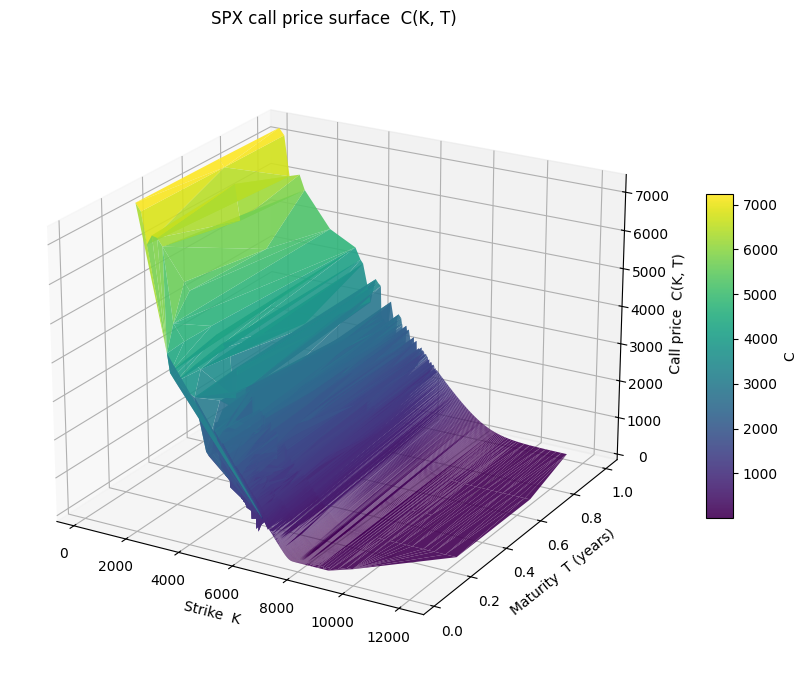

In [10]:
# ---- C(K, T) call price surface ----
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_trisurf(
    calls["strike"], calls["ttm"], calls["mid"],
    cmap=cm.viridis, edgecolor="none", alpha=0.9,
)
ax.set_xlabel("Strike  K")
ax.set_ylabel("Maturity  T (years)")
ax.set_zlabel("Call price  C(K, T)")
ax.set_title("SPX call price surface  C(K, T)")
fig.colorbar(surf, shrink=0.5, aspect=12, label="C")
ax.view_init(elev=22, azim=-60)
fig.tight_layout()
plt.show()

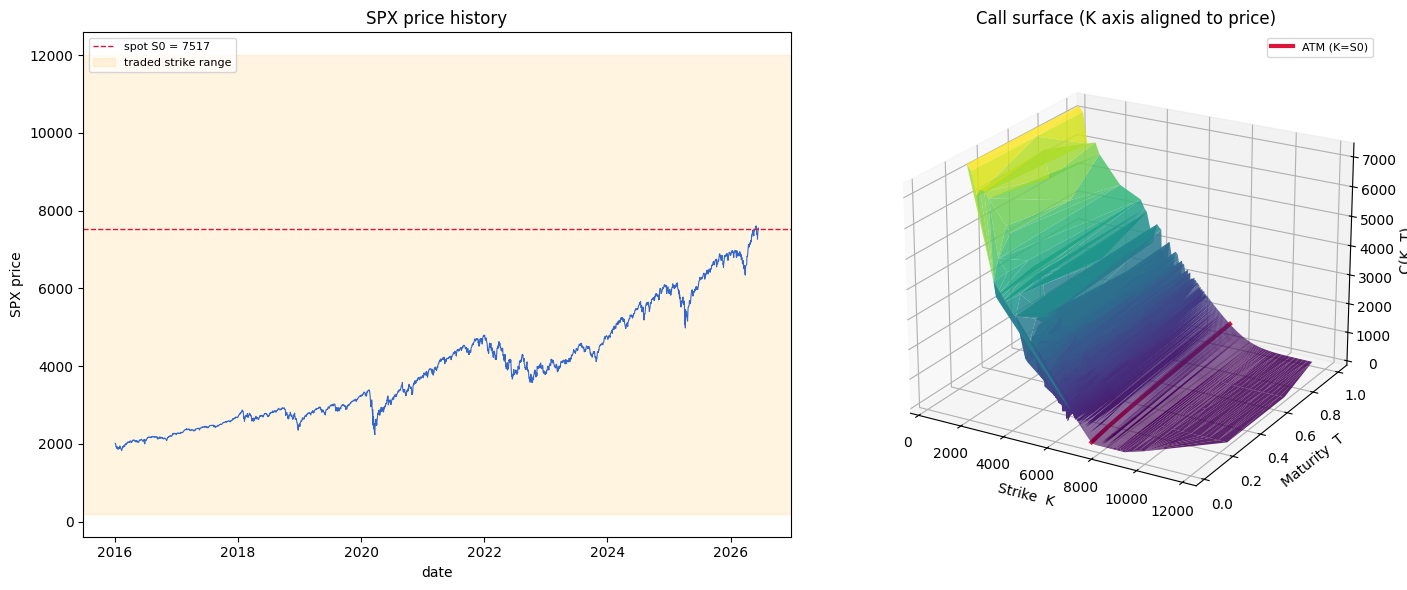

In [11]:
# ---- surface matched to the price series ----
# Left: price history (y-axis = price). Right: surface with its STRIKE axis
fig = plt.figure(figsize=(15, 6))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(spx.index, spx["Close"], lw=0.8, color="#3366cc")
ax1.axhline(S0, color="crimson", ls="--", lw=1, label=f"spot S0 = {S0:.0f}")
ax1.axhspan(calls["strike"].min(), calls["strike"].max(), color="orange",
            alpha=0.12, label="traded strike range")
ax1.set_xlabel("date"); ax1.set_ylabel("SPX price")
ax1.set_title("SPX price history"); ax1.legend(loc="upper left", fontsize=8)
price_range = ax1.get_ylim()

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.plot_trisurf(calls["strike"], calls["ttm"], calls["mid"], cmap=cm.viridis, alpha=0.85)
# ATM ridge: C at K=S0 across maturities
ttm_sorted = sorted(calls["ttm"].unique())
atm = [np.interp(S0, g["strike"], g["mid"]) for _, g in calls.sort_values("strike").groupby("ttm")]
ax2.plot([S0] * len(atm), ttm_sorted, atm, color="crimson", lw=3, label="ATM (K=S0)")
ax2.set_xlim(price_range)               # strike axis aligned to the price y-axis
ax2.set_xlabel("Strike  K"); ax2.set_ylabel("Maturity  T"); ax2.set_zlabel("C(K, T)")
ax2.set_title("Call surface (K axis aligned to price)")
ax2.legend(fontsize=8); ax2.view_init(elev=22, azim=-60)

fig.tight_layout()
plt.show()

<Axes: title={'center': 'Volatility smile for expiry 2026-06-30'}, xlabel='strike'>

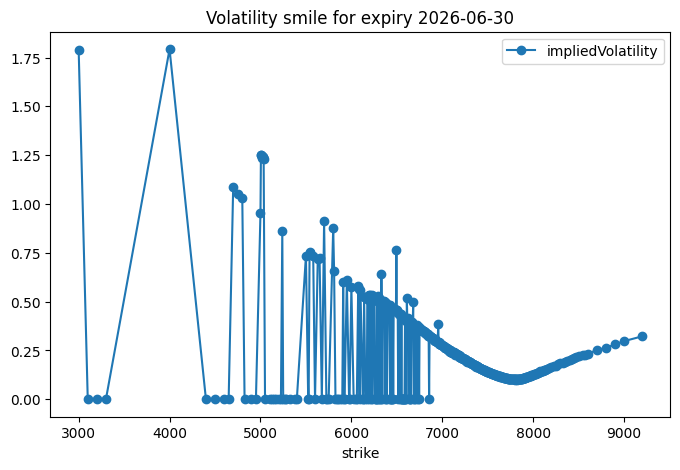

In [12]:
# Draw volatility smile and skew

exp = calls["expiry"].value_counts().index[0]  # pick the most common expiry for a clean smile
one_exp_calls = calls[calls["expiry"] == exp]
one_exp_calls.plot(x="strike", y="impliedVolatility", kind="line", marker="o", figsize=(8, 5), title=f"Volatility smile for expiry {exp}")

## Cleaning + recovered marginals (`SurfacePreprocessor`)

Run the option chain through `SurfacePreprocessor`: liquidity + no-arbitrage (butterfly &
calendar) filtering with put→call parity gives a clean call surface; a raw-SVI fit per
maturity denoises the smile and extrapolates the wings; Breeden–Litzenberger then recovers
the risk-neutral terminal densities $\mu_T(K)=e^{rT}\,\partial^2 C/\partial K^2$ — the
Phase-1 deliverable.

The densities are proper (non-negative, integrate to 1). As a sanity check we print the
**forward-recovery error** $E[S_T]/F-1$: for a true martingale it is zero. On this free
yfinance chain it is sizable at mid maturities — a single flat rate $r$ ignores per-expiry
dividends and the rate term-structure (so $F=\text{spot}\cdot e^{rT}$ is only approximate),
and the thin, illiquid deep wings inflate the tail. That gap is itself a Phase-1 finding
about free-data quality, not a defect of the extraction.

In [ ]:
from src.algorithms.preprocessing import PreprocessConfig, SurfacePreprocessor
from src.algorithms.preprocessing.preprocessing_config import (
    LiquidityConfig,
    MarginalConfig,
)


def implied_rate(chain: pd.DataFrame) -> float:
    """Risk-free rate from put-call parity, median over matched two-sided quotes."""
    rates = []
    for exp, cg in chain[chain.type == "call"].groupby("expiry"):
        pg = chain[(chain.type == "put") & (chain.expiry == exp)]
        m = cg.merge(pg, on="strike", suffixes=("_c", "_p"))
        m = m[(m.bid_c > 0) & (m.ask_c > 0) & (m.bid_p > 0) & (m.ask_p > 0)]
        if len(m) < 3:
            continue
        T = float(m.ttm_c.iloc[0])
        mid_c = (m.bid_c + m.ask_c) / 2
        mid_p = (m.bid_p + m.ask_p) / 2
        slope, _ = np.polyfit(m.strike, mid_c - mid_p, 1)   # C - P = S - K e^{-rT}
        if -slope > 0:
            rates.append(-np.log(-slope) / T)
    return float(np.median(rates)) if rates else 0.04


r = implied_rate(chain)
spot = float(chain.spot.iloc[0])
cfg = PreprocessConfig(
    liquidity=LiquidityConfig(min_volume=0, min_open_interest=1, max_rel_spread=0.05),
    # keep the BL grid near the traded strikes -- far-wing SVI extrapolation is unreliable
    marginal=MarginalConfig(strike_lo=0.4, strike_hi=1.5),
)
pre = SurfacePreprocessor(cfg)
surface = pre.prepare(chain, r=r)
clean, svi, margs = surface.clean, surface.svi, surface.marginals
# ~5 maturities spread across the whole term structure (not just the clustered short end)
pick = sorted({int(round(x)) for x in np.linspace(0, len(svi) - 1, 5)})
print(f"r={r:.4f}  spot={spot:.0f}  clean_quotes={len(clean)}  maturities={clean.ttm.nunique()}")

# Forward-recovery diagnostic: a martingale's marginal has mean E[S_T] = F = spot*e^{rT}.
# Large errors at mid maturities are expected here -- a single flat r ignores per-expiry
# dividends / rate term-structure, and the thin deep wings inflate the tail.
print("\n  T     E[S_T]   forward    err")
for m in margs:
    fwd = spot * np.exp(r * m.ttm)
    print(f"  {m.ttm:5.2f}  {m.mean():7.0f}  {fwd:7.0f}  {100 * (m.mean() / fwd - 1):+6.1f}%")

In [ ]:
# SVI smile fit vs market implied vols, across the term structure (denoised + extrapolated)
fig, ax = plt.subplots(figsize=(9, 5))
for i in pick:
    sp = svi[i]
    g = clean[np.isclose(clean.ttm, sp.t)]
    kg = np.linspace(g.strike.min(), g.strike.max(), 200)
    line, = ax.plot(kg, sp.implied_vol(kg), lw=1.5, label=f"T={sp.t:.2f}")
    ax.scatter(g.strike, g.iv, s=12, alpha=0.5, color=line.get_color())
ax.set_xlabel("strike K"); ax.set_ylabel("implied vol")
ax.set_title("SVI fit (lines) vs market implied vol (dots)")
ax.legend(title="maturity"); fig.tight_layout(); plt.show()

In [ ]:
# Breeden-Litzenberger recovered risk-neutral marginals  mu_T(K) = e^{rT} d2C/dK2
fig, ax = plt.subplots(figsize=(9, 5))
for i in pick:
    m = margs[i]
    ax.plot(m.strikes, m.density, lw=1.5, label=f"T={m.ttm:.2f}  E[S_T]={m.mean():.0f}")
ax.axvline(spot, color="gray", ls="--", lw=0.8, label=f"spot={spot:.0f}")
ax.set_xlim(0.5 * spot, 1.5 * spot)
ax.set_xlabel("terminal price  S_T"); ax.set_ylabel("risk-neutral density")
ax.set_title("Recovered risk-neutral marginals (Breeden-Litzenberger)")
ax.legend(); fig.tight_layout(); plt.show()